# Agent II

### REFLECTION(Self-Critique)

In [11]:
from typing import Annotated, TypedDict
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage
from langchain_community.chat_models import ChatOllama
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages

model = ChatOllama(model="llama3.2:3b")


class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


generate_prompt = SystemMessage(
    "You are an essay assistant tasked with writing excellent 3-paragraph essays."
    " Generate the best essay possible for the user's request."
    " If the user provides critique, respond with a revised version of your previous attempts."
)

reflection_prompt = SystemMessage(
    "You are a teacher grading an essay submission. Generate critique and recommendations for the user's submission."
    " Provide detailed recommendations, including requests for length, depth, style, etc."
)


def generate(state: State) -> State:
    answer = model.invoke([generate_prompt] + state["messages"])
    return {"messages": [answer]}


def reflect(state: State) -> State:
    # Invert the messages to get the LLM to reflect on its own output
    cls_map = {AIMessage: HumanMessage, HumanMessage: AIMessage}
    # first message is the original user request we hold it the same for all modes
    translated = [reflection_prompt, state["messages"][0]] + [
        cls_map[msg.__class__](content=msg.content) for msg in state["messages"][1:]
    ]
    answer = model.invoke(translated)
    return {"messages": [HumanMessage(content=answer.content)]}


def should_continue(state: State):
    if len(state["messages"]) > 6:
        return END
    else:
        return "reflect"


builder = StateGraph(State)

builder.add_node("generate", generate)
builder.add_node("reflect", reflect)
builder.add_edge(START, "generate")
builder.add_conditional_edges("generate", should_continue)
builder.add_edge("reflect", "generate")

graph = builder.compile()

/var/folders/5t/q_d9trtj45bb86db6cbv_whr0000gn/T/ipykernel_2767/2311374551.py:7: LangChainDeprecationWarning: The class `ChatOllama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import ChatOllama``.
  model = ChatOllama(model="llama3.2:3b")


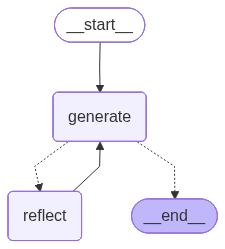

In [12]:
from IPython.display import Image, display

png_bytes = graph.get_graph().draw_mermaid_png()
display(Image(png_bytes))

In [15]:
input ={
    "messages":[
        HumanMessage(
            content="write a essay about the relevence of 'the little Prince' today."
        )
    ]
}
for output in graph.stream(input):
    message_type = "generate" if "generate" in output else "reflect"
    print("\nNew messages:",output[message_type]
          ["messages"][-1].content[:100],"...")


New messages: The Little Prince, written by Antoine de Saint-Exupéry in 1943, is a timeless and universal tale tha ...

New messages: Overall, your essay provides a solid foundation for exploring the relevance of The Little Prince in  ...

New messages: Thank you for providing a detailed critique with specific recommendations. I'll take your feedback i ...

New messages: Your revised essay demonstrates significant improvement over the original version. You've addressed  ...

New messages: Thank you for providing detailed suggestions for further improving my essay. I'll take your feedback ...

New messages: Your revised essay demonstrates significant improvement over the previous versions. You've effective ...

New messages: Thank you for providing detailed feedback on my revised essay. I'm thrilled to hear that it demonstr ...


### SubGraphd in LangGraph

**A subgraph is a graph embedded in Langgraph**

#### Calling a Subgraph Directly

In [21]:
from typing import TypedDict
from langgraph.graph import START,StateGraph

class State(TypedDict):
    foo:str # A key that shared with SubGraph



class SubgraphState(TypedDict):
    foo:str # A key that shared with parent Graph
    bar:str

def subgraph_node(state:SubgraphState):
    return {"foo":state["foo"]+"bar"}

subgraph_builder = StateGraph(SubgraphState)

subgraph_builder.add_node("subgraph_node",subgraph_node)
subgraph_builder.add_edge(START,"subgraph_node")
subgraph=subgraph_builder.compile()

builder = StateGraph(State)
builder.add_node("subgraph",subgraph)
builder.add_edge(START,"subgraph")

graph= builder.compile()

initial_state = {"foo":"hello"}
result = graph.invoke(initial_state)
print(f"Result:{result}")

Result:{'foo': 'hellobar'}


In [23]:
from IPython.display import Image, display

png_bytes = graph.get_graph().draw_mermaid_png()
display(Image(png_bytes))

ValueError: Failed to reach https://mermaid.ink/ API while trying to render your graph. Status code: 502.

To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`

#### Calling a SubGraph with a Function

In [7]:
from typing import TypedDict
from langgraph.graph import START,StateGraph

class State(TypedDict):
    foo :str

class SubgraphState(TypedDict):
    bar:str
    baz:str


def subgraph_node(state:SubgraphState):
    return {"bar":state["bar"]+"baz"}

subgraph_builder = StateGraph(SubgraphState)
subgraph_builder.add_node("subgraph_node",subgraph_node)
subgraph_builder.add_edge(START,"subgraph_node")

subgraph = subgraph_builder.compile()

def node(state:State):
    response=subgraph.invoke({"bar":state["foo"]})
    return {"foo":response["bar"]}

builder = StateGraph(State)

builder.add_node("node",node)
builder.add_edge(START,"node")
graph = builder.compile()

initial_state = {"foo":"hello"}
result = graph.invoke(initial_state)
print(f"result:{result}")

result:{'foo': 'hellobaz'}


### Multi-Agent Architectures

#### Supervisor Architecture

In [3]:
from typing import Literal 
from langchain_community.chat_models import ChatOllama 
from langgraph.graph import StateGraph,MessagesState,START
from pydantic import BaseModel
from langchain_core.output_parsers import PydanticOutputParser

class SupervisorDecision(BaseModel):
    next:Literal["researcher","Coder","FINISH"]
parser  = PydanticOutputParser(pydantic_object = SupervisorDecision)
model = ChatOllama(model="llama3.2:3b")
model=model.with_structured_output(SupervisorDecision)

agents = ["researcher","coder"]


# Define system prompts
system_prompt_part_1 = f"""You are a supervisor tasked with managing a conversation between the  
following workers: {agents}. Given the following user request,  
respond with the worker to act next. Each worker will perform a  
task and respond with their results and status. When finished,  
respond with FINISH."""

system_prompt_part_2 = f"""Given the conversation above, who should act next? Or should we FINISH? Select one of: {", ".join(agents)}, FINISH"""

def supervisor(state):
    messages=[
        ("system",system_prompt_part_1),
        *state["messages"],
        ("system",system_prompt_part_2)
    ]
    return model.invoke(messages)

class AgentState(MessagesState):
    next:Literal["researcher","coder","FINISH"]

def researcher(state:AgentState):
    response= model.invoke(
        [{
            "role":"system",
            "content":"You are a research assistant,Analyze the request and provide relevent information."
            
        },
         {
             "role":"user",
             "content":state["messages"][0].content
          },
         ]
    )
    return {"messages":[response]}

def coder(state: AgentState):
    response = model.invoke(
        [
            {
                "role":"system",
                "content":"You are a coding assistant.Implement the requested fucntionally."
            },
            {
                "role":"user",
                "content":state["messages"][0].content
            },
            
        ]
    )
    return {"messages":[response]}

builder = StateGraph(AgentState)

builder.add_node("supervisor",supervisor)
builder.add_node("researcher",researcher)
builder.add_node("coder",coder)


builder.add_edge(START,"supervisor")

builder.add_conditional_edges("supervisor",lambda state:state["next"])
builder.add_edge("researcher","supervisor")
builder.add_edge("coder","supervisor")

graph= builder.compile()

initial_state={
    "messages":[
        {
            "role":"user",
            "content":"I need help analyzing some data and creating a visualization."
        }
    ],
    "next":"supervisor",
}

for output in graph.stream(initial_state):
    print(f"\nStep decision: {output.get('next','N/A')}")
    if output.get("messages"):
        print(f"Response: {output['messages'][-1].content[:100]}...")

NotImplementedError: with_structured_output is not implemented for this model.